In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.13.0+cu126
CUDA: 12.6
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -U diffusers transformers accelerate safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 104.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

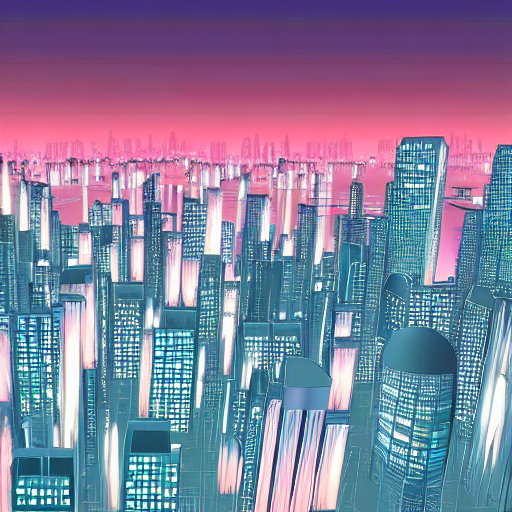

✅ Image generated!
📁 /content/generated_city.png


In [ ]:
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
)

pipe = pipe.to("cuda")

prompt = "A futuristic city skyline at sunset, digital art, highly detailed"

with torch.inference_mode():
    image = pipe(
        prompt=prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]

image.save("/content/generated_city.png")

display(image)

print("✅ Image generated!")
print("📁 /content/generated_city.png")
